<a href="https://colab.research.google.com/github/queleandrade/Aprendizado-de-Maquina---Mestrado/blob/main/CNN_Deforestation_v4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classificação de Desmatamento — ResNet50

> Dataset desbalanceado. Métricas principais: **F1-score** e **AUC-ROC**.

## 1. Kaggle — autenticação e download

In [2]:
import os
from google.colab import userdata

os.environ['KAGGLE_KEY']      = userdata.get('KAGGLE_KEY')
os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')

!kaggle datasets download -d akileshga/deforestation-non-deforestation-area-analysis -p /content/data --unzip
print("Download completo!")

Dataset URL: https://www.kaggle.com/datasets/akileshga/deforestation-non-deforestation-area-analysis
License(s): apache-2.0
100% 44.4M/44.4M [00:00<00:00, 81.0MB/s]

Download completo!


## 2. Imports

In [3]:
import os, shutil, random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, f1_score

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 3. Verificar estrutura do dataset

In [4]:
DATA_DIR = '/content/data'

for cls in os.listdir(DATA_DIR):
    cls_path = os.path.join(DATA_DIR, cls)
    if os.path.isdir(cls_path):
        n = len(os.listdir(cls_path))
        print(f"  {cls}: {n} imagens")

  deforestation: 77 imagens
  no_deforestation: 53 imagens


## 4. Dividir em treino / val / teste (70 / 15 / 15)

In [5]:
random.seed(42)

SPLIT_DIR = '/content/split'

CLASSES = {
    'deforestation':   os.path.join(DATA_DIR, 'deforestation'),
    'nodeforestation': os.path.join(DATA_DIR, 'no_deforestation'),
}

for split in ['train', 'val', 'test']:
    for cls in CLASSES:
        os.makedirs(os.path.join(SPLIT_DIR, split, cls), exist_ok=True)

for cls, src in CLASSES.items():
    files = [f for f in os.listdir(src) if f.lower().endswith(('.jpg','.jpeg','.png','.tif'))]
    random.shuffle(files)

    n_tr  = int(len(files) * 0.70)
    n_val = int(len(files) * 0.15)

    splits = {
        'train': files[:n_tr],
        'val':   files[n_tr:n_tr + n_val],
        'test':  files[n_tr + n_val:],
    }
    for split, flist in splits.items():
        for f in flist:
            shutil.copy(os.path.join(src, f), os.path.join(SPLIT_DIR, split, cls, f))

    print(f"{cls}: treino={len(splits['train'])} | val={len(splits['val'])} | teste={len(splits['test'])}")

deforestation: treino=53 | val=11 | teste=13
nodeforestation: treino=37 | val=7 | teste=9


## 5. Generators com data augmentation

In [6]:
IMG_SIZE   = (224, 224)
BATCH_SIZE = 16  # pequeno porque o dataset é pequeno

# Augmentation forte — essencial com poucos dados para evitar overfitting
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,  # normalização correta do ResNet (não usar rescale aqui)
    rotation_range=60,           # rotaciona até 60 graus
    width_shift_range=0.2,       # desloca horizontalmente
    height_shift_range=0.2,      # desloca verticalmente
    zoom_range=0.4,              # zoom in/out
    shear_range=0.2,             # distorção de cisalhamento
    brightness_range=[0.5, 1.5], # variação de brilho
    horizontal_flip=True,        # espelha horizontal
    vertical_flip=True,          # espelha vertical
    fill_mode='reflect',         # preenche bordas com reflexo
)

# Validação e teste: só normalização, sem augmentation
val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_gen = train_datagen.flow_from_directory(
    os.path.join(SPLIT_DIR, 'train'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True,
)
val_gen = val_test_datagen.flow_from_directory(
    os.path.join(SPLIT_DIR, 'val'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False,
)
test_gen = val_test_datagen.flow_from_directory(
    os.path.join(SPLIT_DIR, 'test'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False,
)

print("Classes:", train_gen.class_indices)
print(f"Treino: {train_gen.samples} | Val: {val_gen.samples} | Teste: {test_gen.samples}")

Found 90 images belonging to 2 classes.
Found 18 images belonging to 2 classes.
Found 22 images belonging to 2 classes.
Classes: {'deforestation': 0, 'nodeforestation': 1}
Treino: 90 | Val: 18 | Teste: 22


## 6. Modelo ResNet50

In [7]:
INPUT_SHAPE = (224, 224, 3)

# ResNet50 pré-treinado no ImageNet — backbone congelado no stage 1
base = ResNet50(input_shape=INPUT_SHAPE, include_top=False, weights='imagenet')
base.trainable = False

inputs = keras.Input(shape=INPUT_SHAPE)
x = base(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation='relu',
                 kernel_regularizer=keras.regularizers.l2(1e-3))(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model = Model(inputs, outputs)

# BinaryFocalCrossentropy: loss nativa do Keras para dados desbalanceados.
# gamma=2.0 — penaliza mais os exemplos difíceis (quanto maior, mais foco nos erros).
# apply_class_balancing=True — aplica peso automático entre as classes.
model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss=keras.losses.BinaryFocalCrossentropy(gamma=2.0, apply_class_balancing=True),
    metrics=[
        keras.metrics.AUC(name='auc'),
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
    ]
)

model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,120,705 (92.01 MB)

 Trainable params: 528,897 (2.02 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

## 7. Stage 1 — treinar só a cabeça (backbone congelado)

In [8]:
history1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30,
    callbacks=[
        ModelCheckpoint('best_model.keras', monitor='val_auc',
                        save_best_only=True, mode='max', verbose=0),
        EarlyStopping(monitor='val_auc', patience=8,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=4, min_lr=1e-7, verbose=1),
    ]
)

Epoch 1/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 33s 3s/step - auc: 0.7642 - loss: 0.6539 - precision: 0.6216 - recall: 0.6216 - val_auc: 0.9740 - val_loss: 0.4700 - val_precision: 1.0000 - val_recall: 0.7143 - learning_rate: 0.0010
Epoch 2/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 430ms/step - auc: 0.8756 - loss: 0.6066 - precision: 0.7105 - recall: 0.7297 - val_auc: 0.9610 - val_loss: 0.5094 - val_precision: 1.0000 - val_recall: 0.5714 - learning_rate: 0.0010
Epoch 3/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 458ms/step - auc: 0.9406 - loss: 0.5308 - precision: 0.9000 - recall: 0.7297 - val_auc: 0.9351 - val_loss: 0.5670 - val_precision: 1.0000 - val_recall: 0.1429 - learning_rate: 0.0010
Epoch 4/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 402ms/step - auc: 0.9398 - loss: 0.5278 - precision: 0.9091 - recall: 0.8108 - val_auc: 0.9675 - val_loss: 0.5492 - val_precision: 1.0000 - val_recall: 0.1429 - learning_rate: 0.0010
Epoch 5/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step - auc: 0.9805 - loss: 0.4958 - precision: 0.9902 - recall: 0.807

## 8. Stage 2 — fine-tuning (descongelar conv4 + conv5)

In [9]:
# Descongela os dois últimos blocos residuais do ResNet50
# conv4 + conv5 — mais capacidade de adaptação ao domínio de satélite
base.trainable = True
for layer in base.layers:
    if 'conv5' not in layer.name and 'conv4' not in layer.name:
        layer.trainable = False

print(f"Camadas treináveis no backbone: {sum(l.trainable for l in base.layers)}")

model.compile(
    optimizer=keras.optimizers.Adam(1e-6),  # LR baixíssimo para não destruir pesos pré-treinados
    loss=keras.losses.BinaryFocalCrossentropy(gamma=2.0, apply_class_balancing=True),
    metrics=[
        keras.metrics.AUC(name='auc'),
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
    ]
)

history2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=60,
    callbacks=[
        ModelCheckpoint('best_model.keras', monitor='val_auc',
                        save_best_only=True, mode='max', verbose=0),
        EarlyStopping(monitor='val_auc', patience=15,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=3, min_lr=1e-7, verbose=1),
    ]
)

Camadas treináveis no backbone: 94
Epoch 1/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 64s 5s/step - auc: 0.8735 - loss: 0.6247 - precision: 0.7586 - recall: 0.5946 - val_auc: 1.0000 - val_loss: 0.4764 - val_precision: 1.0000 - val_recall: 0.5714 - learning_rate: 1.0000e-06
Epoch 2/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 573ms/step - auc: 0.8646 - loss: 0.6105 - precision: 0.8519 - recall: 0.6216 - val_auc: 1.0000 - val_loss: 0.4814 - val_precision: 1.0000 - val_recall: 0.5714 - learning_rate: 1.0000e-06
Epoch 3/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 370ms/step - auc: 0.8582 - loss: 0.6323 - precision: 0.7857 - recall: 0.5946 - val_auc: 1.0000 - val_loss: 0.4862 - val_precision: 1.0000 - val_recall: 0.5714 - learning_rate: 1.0000e-06
Epoch 4/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step - auc: 0.9120 - loss: 0.5201 - precision: 0.9263 - recall: 0.6657
Epoch 4: ReduceLROnPlateau reducing learning rate to 4.999999987376214e-07.
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 406ms/step - auc: 0.9077 - loss: 0.5593 - precision: 0.9000 - recall:

## 9. Curvas de aprendizado (stage 2)

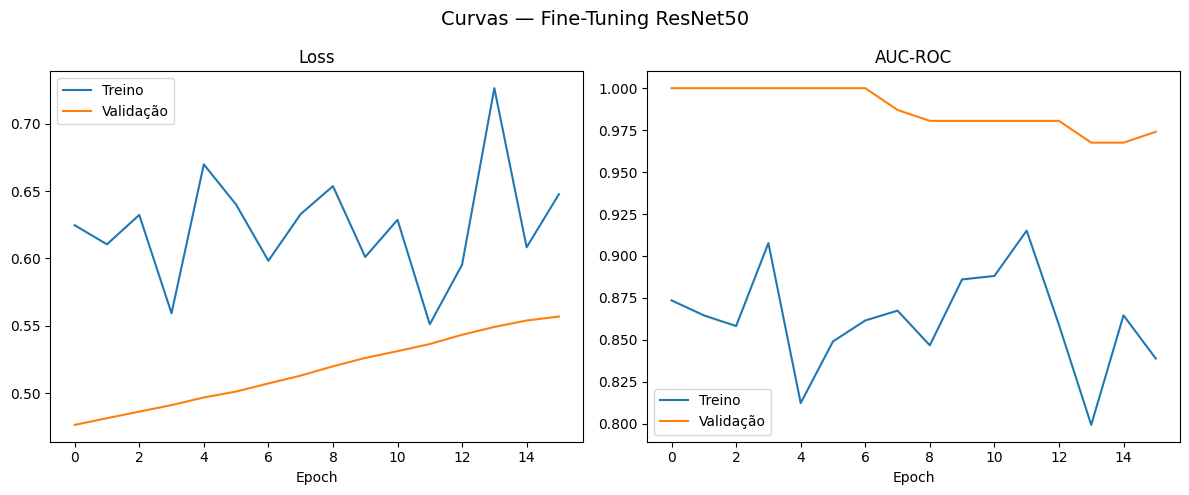

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(history2.history['loss'],     label='Treino')
axes[0].plot(history2.history['val_loss'], label='Validação')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history2.history['auc'],     label='Treino')
axes[1].plot(history2.history['val_auc'], label='Validação')
axes[1].set_title('AUC-ROC')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.suptitle('Curvas — Fine-Tuning ResNet50', fontsize=14)
plt.tight_layout()
plt.show()

## 10. Avaliação no teste + threshold otimizado

In [11]:
best_model = keras.models.load_model('best_model.keras')

test_gen.reset()
y_prob = best_model.predict(test_gen, verbose=1).flatten()
y_true = test_gen.classes

# Busca o threshold que maximiza o F1
# (0.5 fixo não é ideal para dados desbalanceados)
thresholds  = np.arange(0.1, 0.9, 0.01)
f1s         = [f1_score(y_true, (y_prob > t).astype(int), zero_division=0) for t in thresholds]
best_thresh = thresholds[np.argmax(f1s)]
y_pred      = (y_prob > best_thresh).astype(int)

class_labels = list(test_gen.class_indices.keys())

print(f"Melhor threshold: {best_thresh:.2f}  |  F1: {max(f1s):.4f}")
print(f"AUC-ROC: {roc_auc_score(y_true, y_prob):.4f}\n")
print("=== Classification Report ===")
print(classification_report(y_true, y_pred, target_names=class_labels))

2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 5s/step
Melhor threshold: 0.10  |  F1: 0.8889
AUC-ROC: 0.9658

=== Classification Report ===
                 precision    recall  f1-score   support

  deforestation       0.92      0.92      0.92        13
nodeforestation       0.89      0.89      0.89         9

       accuracy                           0.91        22
      macro avg       0.91      0.91      0.91        22
   weighted avg       0.91      0.91      0.91        22



## 11. Matriz de confusão + curva ROC

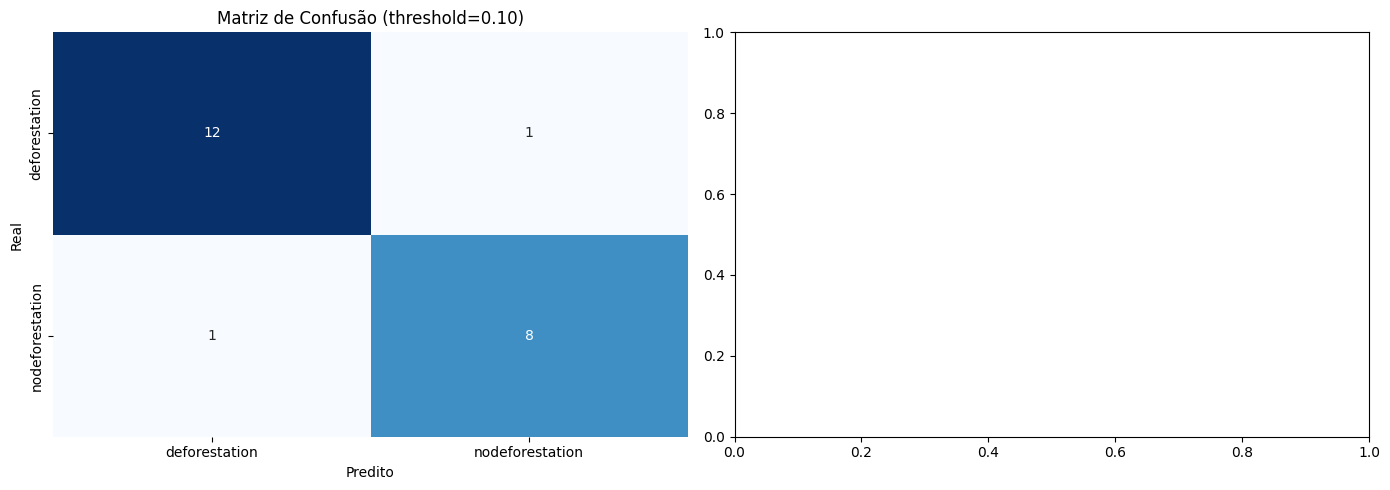

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels,
            ax=axes[0], cbar=False)
axes[0].set_xlabel('Predito')
axes[0].set_ylabel('Real')
axes[0].set_title(f'Matriz de Confusão (threshold={best_thresh:.2f})')

# fpr, tpr, _ = roc_curve(y_true, y_prob)
# axes[1].plot(fpr, tpr, lw=2, label=f'AUC = {roc_auc_score(y_true, y_prob):.4f}')
# axes[1].plot([0,1],[0,1],'--', color='gray')
# axes[1].set_xlabel('FPR')
# axes[1].set_ylabel('TPR')
# axes[1].set_title('Curva ROC')
# axes[1].legend()

plt.tight_layout()
plt.show()